# GBS v3 - Evento: Declínio por Distância do Pico
## Case Declínio de SKU - Grupo Boticário

**Evento:** % do pico < 20% + ciclos desde pico >= 15 + perda de capilaridade

**Features:** ~15 variáveis otimizadas (sem leakage)

**Previsão:** P(declinar próx 25 ciclos | vivo hoje) = 1 - S(t+25)/S(t)

**Autor:** Gustavo

---
## 1. Setup

In [1]:
!pip install scikit-survival -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 7.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.nonparametric import kaplan_meier_estimator

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

FIGURES_DIR = '/content/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
HORIZONTE = 25
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


---
## 2. Carregamento e Tratamento

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Ajuste o caminho abaixo conforme a localização do arquivo no seu Drive
filepath = '/content/drive/MyDrive/Case SKU/data/base-de-dados.csv'
df = pd.read_csv(filepath, thousands='.')
print(f'Dados carregados com sucesso: {df.shape[0]} linhas x {df.shape[1]} colunas')

Mounted at /content/drive
Dados carregados com sucesso: 126781 linhas x 22 colunas


In [5]:
# Tratamento de tipos
cols_object = df.select_dtypes(include=['object']).columns.tolist()
cols_excluir = ['sk_produto_case','cod_canal_portfolio','des_categoria_portfolio','des_status_atual_agrup']
for col in cols_object:
    if col not in cols_excluir:
        amostra = df[col].dropna().head(100).astype(str)
        if amostra.str.match(r'^[\d\s\.\,\-\+R\$%]+$').mean() > 0.7:
            serie = df[col].astype(str).str.strip().str.replace('.','',regex=False).str.replace(',','.',regex=False)
            df[col] = pd.to_numeric(serie, errors='coerce')
print('Tratamento concluído!')

Tratamento concluído!


---
## 3. Definição do Evento: Declínio por Distância do Pico (v2)

In [6]:
# ============================================================
# EVENTO v2: Declínio por Distância do Pico
# Critérios:
#   1. Receita < 20% do pico histórico (faixa de risco)
#   2. Ciclos desde o pico >= 15 (obsolescência)
#   3. Base de PDVs caindo (perda de capilaridade)
#   4. Confirmação por 4 ciclos (evita ruído sazonal)
# ============================================================

ciclos_ordenados = sorted(df['cod_ciclo'].unique())
mapa_ciclo = {ciclo: idx for idx, ciclo in enumerate(ciclos_ordenados)}
df['ordem_ciclo'] = df['cod_ciclo'].map(mapa_ciclo)

def definir_evento_declinio_v2(df, janela=4):
    df = df.sort_values(['sk_produto_case', 'cod_ciclo'])
    group = df.groupby('sk_produto_case')

    # Perda de capilaridade
    df['slope_cpfs_total'] = group['ind_cpfs_total'].diff()

    # Pico histórico (cummax)
    df['pico_historico'] = group['ind_vlr_receita_real_dia_corrigido'].transform(
        lambda x: x.expanding().max()
    )
    df['perc_do_pico'] = (
        df['ind_vlr_receita_real_dia_corrigido'] /
        df['pico_historico'].replace(0, np.nan)
    )

    # Ciclos desde o pico
    def calc_ciclos_desde_pico(serie):
        resultado = []
        pico_val = -np.inf
        ciclo_pico = 0
        for i, val in enumerate(serie):
            if val >= pico_val:
                pico_val = val
                ciclo_pico = i
            resultado.append(i - ciclo_pico)
        return pd.Series(resultado, index=serie.index)

    df['ciclos_desde_pico'] = group['ind_vlr_receita_real_dia_corrigido'].transform(calc_ciclos_desde_pico)

    # DEFINIÇÃO DO EVENTO ROBUSTO
    df['sinal_declinio_robusto'] = (
        (df['perc_do_pico'] < 0.20) &             # < 20% do pico histórico
        (df['ciclos_desde_pico'] >= 15) &         # >= 15 ciclos sem renovar pico
        (df['slope_cpfs_total'] < 0)              # Perdendo lojas
    ).astype(int)

    # Janela de confirmação (4 ciclos)
    df['evento_declinio'] = group['sinal_declinio_robusto'].transform(
        lambda x: x.rolling(window=janela).sum() >= (janela - 1)
    ).astype(int)

    return df

df = definir_evento_declinio_v2(df, janela=4)

# Tempo até o evento
def calc_tempo(grupo):
    primeiro = grupo['ordem_ciclo'].min()
    eventos = grupo[grupo['evento_declinio']==1]['ordem_ciclo']
    if len(eventos) > 0:
        return pd.Series({'duracao': max(eventos.min()-primeiro+1, 1), 'evento': True})
    return pd.Series({'duracao': max(grupo['ordem_ciclo'].max()-primeiro+1, 1), 'evento': False})

vida_produto = df.groupby('sk_produto_case').apply(calc_tempo).reset_index()
vida_produto['evento'] = vida_produto['evento'].astype(bool)
vida_produto['duracao'] = vida_produto['duracao'].astype(float)

print('='*60)
print('EVENTO v2: DECLÍNIO POR DISTÂNCIA DO PICO')
print('='*60)
print(f'  Critérios: <20% pico + >=15 ciclos sem pico + PDVs caindo')
print(f'  Confirmação: 4 ciclos')
print(f'\n  Produtos: {len(vida_produto)}')
print(f'  Com declínio: {vida_produto["evento"].sum()} ({vida_produto["evento"].mean()*100:.1f}%)')
print(f'  Censurados: {(~vida_produto["evento"]).sum()} ({(~vida_produto["evento"]).mean()*100:.1f}%)')
print(f'  Duração média até evento: {vida_produto[vida_produto["evento"]]["duracao"].mean():.1f} ciclos')

EVENTO v2: DECLÍNIO POR DISTÂNCIA DO PICO
  Critérios: <20% pico + >=15 ciclos sem pico + PDVs caindo
  Confirmação: 4 ciclos

  Produtos: 2462
  Com declínio: 1230 (50.0%)
  Censurados: 1232 (50.0%)
  Duração média até evento: 38.9 ciclos


---
## 4. Feature Engineering

In [7]:
# ============================================================
# FEATURE ENGINEERING v3
# ============================================================

vars_base = [
    'ind_cpfs_novos', 'ind_cpfs_total',
    'ind_vlr_receita_real_dia_corrigido', 'ind_vlr_receita_real_corrigido',
    'ind_vlr_ruptura', 'ind_qtd_ciclos_agrupador',
]
vars_base = [v for v in vars_base if v in df.columns]

df_sorted = df.sort_values(['sk_produto_case', 'ordem_ciclo'])

# Colunas derivadas ANTES dos subsets
df_sorted['flag_ruptura'] = (df_sorted['ind_vlr_ruptura'] > 0).astype(int)
df_sorted['receita_por_cpf'] = (
    df_sorted['ind_vlr_receita_real_dia_corrigido'] /
    df_sorted['ind_cpfs_total'].replace(0, np.nan)
)

# Subsets temporais
df_ultimos5 = df_sorted.groupby('sk_produto_case').tail(5)
df_ultimos10 = df_sorted.groupby('sk_produto_case').tail(10)

# SLOPES
def calc_slope(g, v):
    x = np.arange(len(g)); y = g[v].values
    mask = ~np.isnan(y)
    if mask.sum() >= 3: return stats.linregress(x[mask], y[mask])[0]
    return 0

vars_slope = ['ind_cpfs_novos','ind_cpfs_total','ind_vlr_receita_real_dia_corrigido','ind_vlr_ruptura']
vars_slope = [v for v in vars_slope if v in df.columns]

slopes_5 = {}
for var in vars_slope:
    slopes_5[f'{var}_slope_ult5'] = df_ultimos5.groupby('sk_produto_case').apply(lambda g,v=var: calc_slope(g,v))
feat_slope_5 = pd.DataFrame(slopes_5)

slopes_10 = {}
for var in vars_slope:
    slopes_10[f'{var}_slope_ult10'] = df_ultimos10.groupby('sk_produto_case').apply(lambda g,v=var: calc_slope(g,v))
feat_slope_10 = pd.DataFrame(slopes_10)

# MÉDIAS
feat_media = df_sorted.groupby('sk_produto_case')[vars_base].mean()
feat_media.columns = [f'{c}_media' for c in feat_media.columns]

# TICKET MÉDIO
feat_ticket = df_sorted.groupby('sk_produto_case')['receita_por_cpf'].mean().reset_index(name='ticket_medio_media')
feat_ticket_slope = df_sorted.groupby('sk_produto_case').apply(
    lambda g: calc_slope(g, 'receita_por_cpf')
).rename('ticket_medio_slope').reset_index()

# RUPTURA
ruptura_ult10 = df_ultimos10.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='prop_ruptura_ult10')
ruptura_global = df_sorted.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='prop_ruptura')

# IDADE (apenas phase_in)
feat_idade = pd.DataFrame({'sk_produto_case': df['sk_produto_case'].unique()})
if 'cod_phase_in_agrup' in df.columns:
    df['ordem_phase_in'] = df['cod_phase_in_agrup'].map(mapa_ciclo)
    pi = df.groupby('sk_produto_case')['ordem_phase_in'].first().reset_index()
    ult = df.groupby('sk_produto_case')['ordem_ciclo'].max().reset_index(name='ult_obs')
    feat_idade = feat_idade.merge(pi, on='sk_produto_case', how='left')
    feat_idade = feat_idade.merge(ult, on='sk_produto_case', how='left')
    feat_idade['idade_produto'] = feat_idade['ult_obs'] - feat_idade['ordem_phase_in']
    feat_idade = feat_idade.drop(columns=['ordem_phase_in','ult_obs'], errors='ignore')

# DISTÂNCIA DO PICO (última observação por produto)
df_sorted['pico_hist'] = df_sorted.groupby('sk_produto_case')['ind_vlr_receita_real_dia_corrigido'].transform(lambda x: x.expanding().max())
df_sorted['pct_pico'] = df_sorted['ind_vlr_receita_real_dia_corrigido'] / df_sorted['pico_hist'].replace(0, np.nan)

def calc_ciclos_desde_pico(serie):
    resultado = []
    pico_val = -np.inf
    ciclo_pico = 0
    for i, val in enumerate(serie):
        if val >= pico_val:
            pico_val = val
            ciclo_pico = i
        resultado.append(i - ciclo_pico)
    return pd.Series(resultado, index=serie.index)

df_sorted['ciclos_desde_pico'] = df_sorted.groupby('sk_produto_case')['ind_vlr_receita_real_dia_corrigido'].transform(calc_ciclos_desde_pico)
feat_pico = df_sorted.groupby('sk_produto_case').tail(1)[['sk_produto_case','pct_pico','ciclos_desde_pico']].copy()
feat_pico.columns = ['sk_produto_case','pct_pico_atual','ciclos_desde_pico_atual']

# ACELERAÇÃO (slope_ult5 - slope_ult10)
feat_aceleracao = feat_slope_5.reset_index().merge(feat_slope_10.reset_index(), on='sk_produto_case', how='left')
for var in vars_slope:
    feat_aceleracao[f'{var}_aceleracao'] = feat_aceleracao[f'{var}_slope_ult5'] - feat_aceleracao[f'{var}_slope_ult10']
feat_aceleracao = feat_aceleracao[['sk_produto_case'] + [c for c in feat_aceleracao.columns if '_aceleracao' in c]]

# MÉDIAS MÓVEIS (últimos valores de mm3 e mm5)
vars_mm = ['ind_cpfs_novos','ind_cpfs_total','ind_vlr_receita_real_dia_corrigido']
vars_mm = [v for v in vars_mm if v in df.columns]
for var in vars_mm:
    df_sorted[f'{var}_mm3'] = df_sorted.groupby('sk_produto_case')[var].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df_sorted[f'{var}_mm5'] = df_sorted.groupby('sk_produto_case')[var].transform(lambda x: x.rolling(5, min_periods=1).mean())
cols_mm = [c for c in df_sorted.columns if '_mm3' in c or '_mm5' in c]
feat_mm = df_sorted.groupby('sk_produto_case')[cols_mm].last().reset_index()

# LAGS (último valor)
feat_lags = pd.DataFrame({'sk_produto_case': df['sk_produto_case'].unique()})
for var in ['ind_vlr_receita_real_dia_corrigido','ind_cpfs_novos','ind_cpfs_total']:
    if var in df.columns:
        ultimo = df_sorted.groupby('sk_produto_case')[var].last().reset_index(name=f'{var}_ultimo')
        feat_lags = feat_lags.merge(ultimo, on='sk_produto_case', how='left')

print('Feature Engineering v3 concluído! (com pico, aceleração, MM, lags)')

Feature Engineering v3 concluído! (com pico, aceleração, MM, lags)


---
## 5. Dataset Final

In [8]:
df_surv = vida_produto[['sk_produto_case','duracao','evento']].copy()
df_surv = df_surv.merge(feat_media.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_5.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_10.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket_slope, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura_ult10, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura_global, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_idade, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_pico, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_aceleracao, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_mm, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_lags, on='sk_produto_case', how='left')

feature_cols = [c for c in df_surv.columns if c not in ['sk_produto_case','duracao','evento']]
df_surv[feature_cols] = df_surv[feature_cols].replace([np.inf,-np.inf], np.nan)
df_surv[feature_cols] = df_surv[feature_cols].fillna(df_surv[feature_cols].median())

print(f'Dataset: {len(df_surv)} produtos | {len(feature_cols)} features')
print(f'\nFeatures ({len(feature_cols)}):')
for f in sorted(feature_cols): print(f'  - {f}')

Dataset: 2462 produtos | 34 features

Features (34):
  - ciclos_desde_pico_atual
  - idade_produto
  - ind_cpfs_novos_aceleracao
  - ind_cpfs_novos_media
  - ind_cpfs_novos_mm3
  - ind_cpfs_novos_mm5
  - ind_cpfs_novos_slope_ult10
  - ind_cpfs_novos_slope_ult5
  - ind_cpfs_novos_ultimo
  - ind_cpfs_total_aceleracao
  - ind_cpfs_total_media
  - ind_cpfs_total_mm3
  - ind_cpfs_total_mm5
  - ind_cpfs_total_slope_ult10
  - ind_cpfs_total_slope_ult5
  - ind_cpfs_total_ultimo
  - ind_qtd_ciclos_agrupador_media
  - ind_vlr_receita_real_corrigido_media
  - ind_vlr_receita_real_dia_corrigido_aceleracao
  - ind_vlr_receita_real_dia_corrigido_media
  - ind_vlr_receita_real_dia_corrigido_mm3
  - ind_vlr_receita_real_dia_corrigido_mm5
  - ind_vlr_receita_real_dia_corrigido_slope_ult10
  - ind_vlr_receita_real_dia_corrigido_slope_ult5
  - ind_vlr_receita_real_dia_corrigido_ultimo
  - ind_vlr_ruptura_aceleracao
  - ind_vlr_ruptura_media
  - ind_vlr_ruptura_slope_ult10
  - ind_vlr_ruptura_slope_ult5
 

---
## 6. Split Treino / Teste

In [9]:
X = df_surv[feature_cols].values
y = np.array([(e,d) for e,d in zip(df_surv['evento'],df_surv['duracao'])], dtype=[('evento',bool),('duracao',float)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=df_surv['evento'].astype(int))
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Treino: {len(X_train)} ({y_train["evento"].sum()} eventos)')
print(f'Teste:  {len(X_test)} ({y_test["evento"].sum()} eventos)')

Treino: 1846 (922 eventos)
Teste:  616 (308 eventos)


---
## 7. Treinamento

In [10]:
gbs = GradientBoostingSurvivalAnalysis(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_samples_split=10, min_samples_leaf=5,
    subsample=0.8, max_features='sqrt',
    dropout_rate=0.1, random_state=42, verbose=1,
)
print('Treinando...')
gbs.fit(X_train_s, y_train)
c_train = gbs.score(X_train_s, y_train)
c_test = gbs.score(X_test_s, y_test)
print(f'\nC-Index Treino: {c_train:.4f}')
print(f'C-Index Teste:  {c_test:.4f}')
print(f'Gap: {c_train-c_test:.4f}')
print(f'\n0.5=random | 0.7=bom | 0.8=excelente')

Treinando...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1        4483.5756           0.0000           18.33s
         2        4521.3499          33.8918           18.05s
         3        4478.8276         -31.8063           17.89s
         4        4498.8258          17.7060           17.97s
         5        4521.4457          17.8672           17.89s
         6        4523.4201           0.0867           17.80s
         7        4464.8703         -42.3515           17.75s
         8        4611.0014         115.1171           17.72s
         9        4418.4907        -141.4790           17.67s
        10        4554.0577         105.2801           17.60s
        20        4477.3610         -38.9591           17.48s
        30        4554.5762           8.7690           17.18s
        40        4491.0197          24.2071           16.65s
        50        4493.7709           7.4415           16.21s
        60        4421.2986           6.2449           1

---
## 8. Avaliação

C-Index: 0.7458 | Concordantes: 51544 | Discordantes: 17571


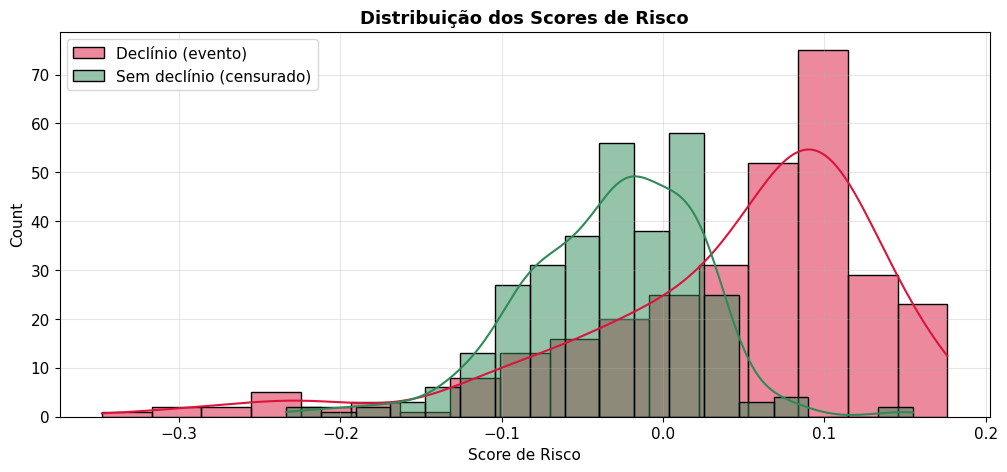

In [11]:
risk_scores = gbs.predict(X_test_s)
c_idx, concordant, discordant, _, _ = concordance_index_censored(y_test['evento'], y_test['duracao'], risk_scores)
print(f'C-Index: {c_idx:.4f} | Concordantes: {concordant} | Discordantes: {discordant}')

plt.figure(figsize=(12,5))
sns.histplot(risk_scores[y_test['evento']], kde=True, color='crimson', alpha=0.5, label='Declínio (evento)')
sns.histplot(risk_scores[~y_test['evento']], kde=True, color='seagreen', alpha=0.5, label='Sem declínio (censurado)')
plt.title('Distribuição dos Scores de Risco', fontsize=13, fontweight='bold')
plt.xlabel('Score de Risco')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 9. Feature Importance

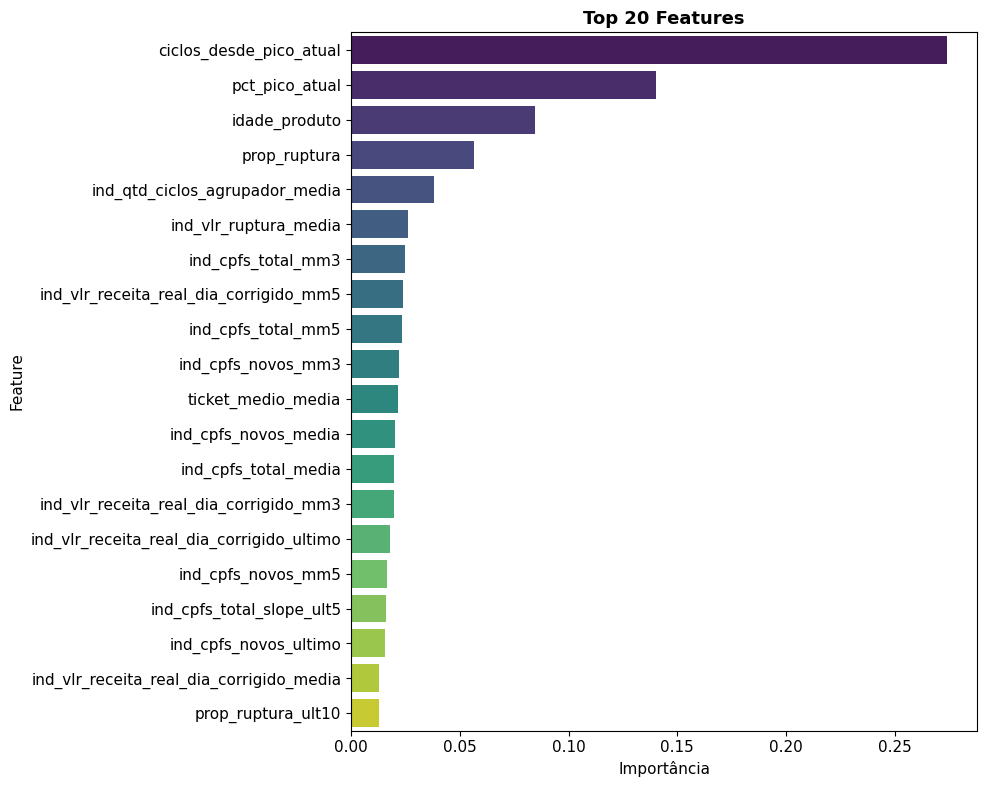

                                  Feature  Importância
                  ciclos_desde_pico_atual     0.274108
                           pct_pico_atual     0.140382
                            idade_produto     0.084551
                             prop_ruptura     0.056439
           ind_qtd_ciclos_agrupador_media     0.038161
                    ind_vlr_ruptura_media     0.026089
                       ind_cpfs_total_mm3     0.024669
   ind_vlr_receita_real_dia_corrigido_mm5     0.023859
                       ind_cpfs_total_mm5     0.023376
                       ind_cpfs_novos_mm3     0.022248
                       ticket_medio_media     0.021585
                     ind_cpfs_novos_media     0.020207
                     ind_cpfs_total_media     0.019852
   ind_vlr_receita_real_dia_corrigido_mm3     0.019735
ind_vlr_receita_real_dia_corrigido_ultimo     0.018097


In [12]:
imp = pd.DataFrame({'Feature': feature_cols, 'Importância': gbs.feature_importances_}).sort_values('Importância', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=imp.head(20), x='Importância', y='Feature', palette='viridis')
plt.title('Top 20 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(imp.head(15).to_string(index=False))

---
## 10. Kaplan-Meier por Grupo de Risco

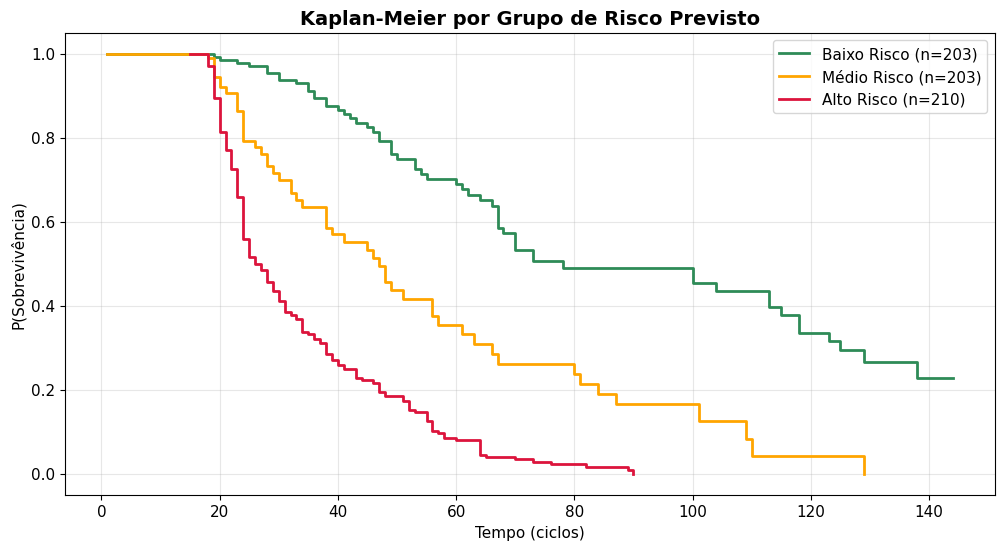

Curvas separadas = modelo discrimina bem!


In [13]:
tercis = np.percentile(risk_scores, [33, 66])
grupos = np.digitize(risk_scores, tercis)
plt.figure(figsize=(12, 6))
for g, (label, cor) in enumerate(zip(['Baixo','Médio','Alto'],['seagreen','orange','crimson'])):
    mask = grupos == g
    if mask.sum() > 0:
        t, s = kaplan_meier_estimator(y_test['evento'][mask], y_test['duracao'][mask])
        plt.step(t, s, where='post', lw=2, color=cor, label=f'{label} Risco (n={mask.sum()})')
plt.title('Kaplan-Meier por Grupo de Risco Previsto', fontsize=14, fontweight='bold')
plt.xlabel('Tempo (ciclos)')
plt.ylabel('P(Sobrevivência)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print('Curvas separadas = modelo discrimina bem!')

---
## 11. Previsão Condicional (Próximos 25 Ciclos)

In [14]:
# ============================================================
# P(T < t+25 | T > t) = 1 - S(t+25) / S(t)
# ============================================================

df_vivos = df_surv[df_surv['evento'] == False].copy()
print(f'Prevendo para {len(df_vivos)} produtos SEM evento\n')

X_vivos = df_vivos[feature_cols].values
X_vivos_s = scaler.transform(X_vivos)
surv_vivos = gbs.predict_survival_function(X_vivos_s)
risk_vivos = gbs.predict(X_vivos_s)

prob_proximos_25 = []
ciclo_declinio_list = []

for i, fn in enumerate(surv_vivos):
    t_atual = df_vivos.iloc[i]['duracao']
    t_futuro = t_atual + HORIZONTE
    s_atual = fn(min(t_atual, fn.x.max()))
    s_futuro = fn(min(t_futuro, fn.x.max()))
    prob_cond = np.clip(1 - (s_futuro / s_atual), 0, 1) if s_atual > 0 else 1.0
    prob_proximos_25.append(prob_cond)

    ciclo_decl = np.nan
    for delta in range(1, HORIZONTE + 1):
        t_check = t_atual + delta
        if t_check <= fn.x.max():
            s_check = fn(t_check)
            if s_atual > 0 and (1 - s_check/s_atual) >= 0.5:
                ciclo_decl = delta
                break
    ciclo_declinio_list.append(ciclo_decl)

df_vivos['risk_score'] = risk_vivos
df_vivos['prob_declinio_proximos_25'] = prob_proximos_25
df_vivos['ciclo_declinio_previsto'] = ciclo_declinio_list
df_vivos['previsao_declina'] = (df_vivos['prob_declinio_proximos_25'] > 0.5).astype(int)

print('='*60)
print('PREVISÃO: PRÓXIMOS 25 CICLOS')
print('='*60)
print(f'\nCom previsão de declínio (>50%): {df_vivos["previsao_declina"].sum()}')
print(f'Sem previsão: {(1-df_vivos["previsao_declina"]).sum()}')
print(f'\nDistribuição:')
print(df_vivos['prob_declinio_proximos_25'].describe())

declina = df_vivos[df_vivos['previsao_declina']==1]
if len(declina)>0:
    print(f'\nCiclo médio: {declina["ciclo_declinio_previsto"].mean():.1f}')
    print(f'Ciclo mediano: {declina["ciclo_declinio_previsto"].median():.1f}')

Prevendo para 1232 produtos SEM evento

PREVISÃO: PRÓXIMOS 25 CICLOS

Com previsão de declínio (>50%): 175
Sem previsão: 1057

Distribuição:
count    1232.000000
mean        0.404315
std         0.100535
min         0.000000
25%         0.332719
50%         0.432213
75%         0.480861
max         0.589554
Name: prob_declinio_proximos_25, dtype: float64

Ciclo médio: 23.9
Ciclo mediano: 24.0


---
## 12. Visualizações e Top Risco

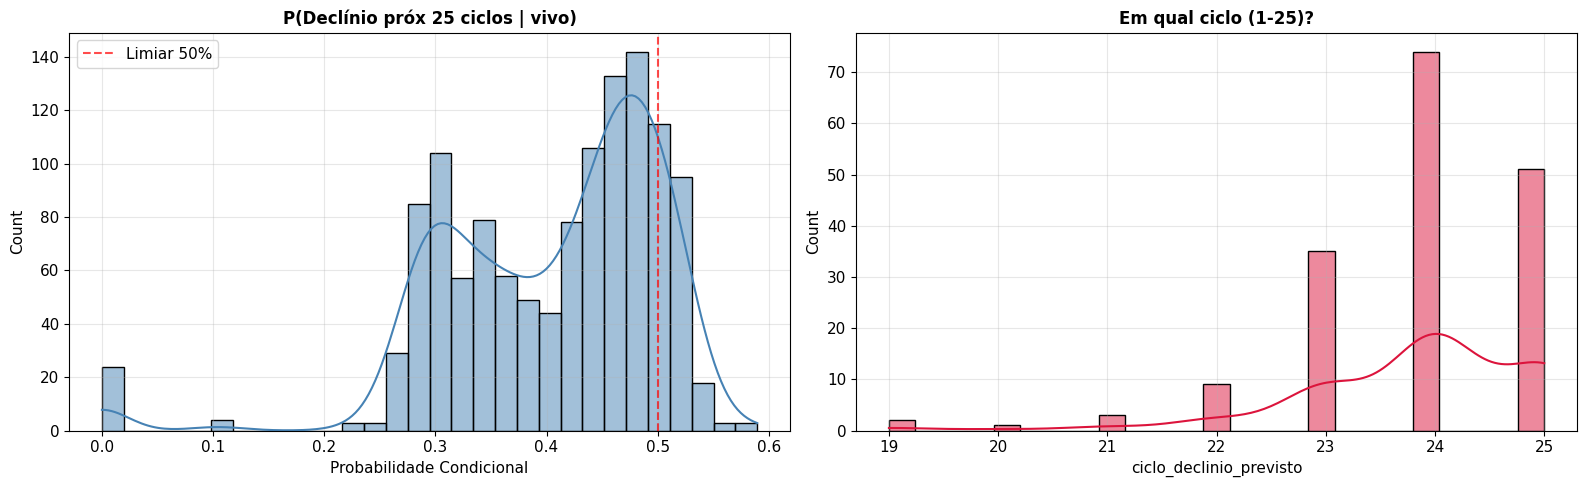

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_vivos['prob_declinio_proximos_25'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(0.5, ls='--', color='red', alpha=0.7, label='Limiar 50%')
axes[0].set_title('P(Declínio próx 25 ciclos | vivo)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Probabilidade Condicional')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ciclos_v = df_vivos['ciclo_declinio_previsto'].dropna()
if len(ciclos_v) > 0:
    sns.histplot(ciclos_v, bins=25, kde=True, color='crimson', ax=axes[1])
    axes[1].set_title('Em qual ciclo (1-25)?', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5,0.5,'Nenhum >50%',ha='center',va='center',fontsize=12)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print('--- Top 20 Produtos com MAIOR risco ---')
top = df_vivos.sort_values('prob_declinio_proximos_25', ascending=False).head(20)
display(top[['sk_produto_case','duracao','prob_declinio_proximos_25','ciclo_declinio_previsto','risk_score']])

--- Top 20 Produtos com MAIOR risco ---


,sk_produto_case,duracao,prob_declinio_proximos_25,ciclo_declinio_previsto,risk_score
871,872,45.0,0.589554,21.0,0.101707
2097,2098,43.0,0.589396,21.0,0.154960
1604,1605,48.0,0.586849,19.0,0.103195
2071,2072,47.0,0.566553,20.0,0.049635
824,825,53.0,0.563634,19.0,0.136518
1646,1647,47.0,0.560006,21.0,0.031539
1800,1801,45.0,0.546349,22.0,-0.017514
794,795,38.0,0.545005,22.0,0.132816
1015,1016,44.0,0.544595,23.0,0.014073
845,846,47.0,0.542829,22.0,-0.016231


---
## 13. Resumo Final

In [17]:
print('='*60)
print('  RESUMO - GBS v3 (Evento: Distância do Pico)')
print('='*60)
print(f'\n  Evento: <20% pico + >=15 ciclos sem pico + PDVs caindo')
print(f'  Modelo: Gradient Boosting Survival')
print(f'  Horizonte: {HORIZONTE} ciclos (condicional)')
print(f'  Features: {len(feature_cols)}')
print(f'  C-Index Treino: {c_train:.4f}')
print(f'  C-Index Teste:  {c_test:.4f}')
print(f'  Gap: {c_train-c_test:.4f}')
print(f'  Em risco (>50%): {df_vivos["previsao_declina"].sum()}/{len(df_vivos)}')
print('='*60)

  RESUMO - GBS v3 (Evento: Distância do Pico)

  Evento: <20% pico + >=15 ciclos sem pico + PDVs caindo
  Modelo: Gradient Boosting Survival
  Horizonte: 25 ciclos (condicional)
  Features: 34
  C-Index Treino: 0.7512
  C-Index Teste:  0.7458
  Gap: 0.0054
  Em risco (>50%): 175/1232


---
## 14. Análise de Proteção de Margem (Output do Modelo)

In [18]:
# ============================================================
# PROTEÇÃO DE MARGEM - USANDO OUTPUT DO MODELO GBS
# ============================================================

print('='*70)
print('  ANÁLISE DE PROTEÇÃO DE MARGEM')
print('  Baseada no output do Gradient Boosting Survival')
print('='*70)

# Enriquecer df_vivos com indicadores adicionais
df_margem = df_vivos.copy()

# Adicionar pct_pico e ciclos_desde_pico
pico_atual = df_sorted.groupby('sk_produto_case').tail(1)[['sk_produto_case','pct_pico','ciclos_desde_pico']].copy()
slope_cpfs = df_ultimos10.groupby('sk_produto_case').apply(lambda g: calc_slope(g,'ind_cpfs_total')).reset_index(name='slope_cpfs_ult10')
ruptura_rec = df_ultimos10.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='ruptura_ult10')
ticket_atual = df_sorted.groupby('sk_produto_case')['receita_por_cpf'].last().reset_index(name='ticket_atual')
ticket_mediana = df_sorted.groupby('sk_produto_case')['receita_por_cpf'].median().reset_index(name='ticket_mediana')

df_margem = df_margem.merge(pico_atual, on='sk_produto_case', how='left')
df_margem = df_margem.merge(slope_cpfs, on='sk_produto_case', how='left')
df_margem = df_margem.merge(ruptura_rec, on='sk_produto_case', how='left')
df_margem = df_margem.merge(ticket_atual, on='sk_produto_case', how='left')
df_margem = df_margem.merge(ticket_mediana, on='sk_produto_case', how='left')

n_ativos = len(df_margem)
print(f'\nProdutos ativos analisados: {n_ativos}')

  ANÁLISE DE PROTEÇÃO DE MARGEM
  Baseada no output do Gradient Boosting Survival

Produtos ativos analisados: 1232



--- Política de Preços (baseada no modelo) ---



,Quantidade,% Portfólio
politica,,
MÉDIO - Suspender novos lotes e repacking,868,70.5
BAIXO - Manter preço e investimento,189,15.3
ALTO - Redução 10-15% e suspender produção,175,14.2


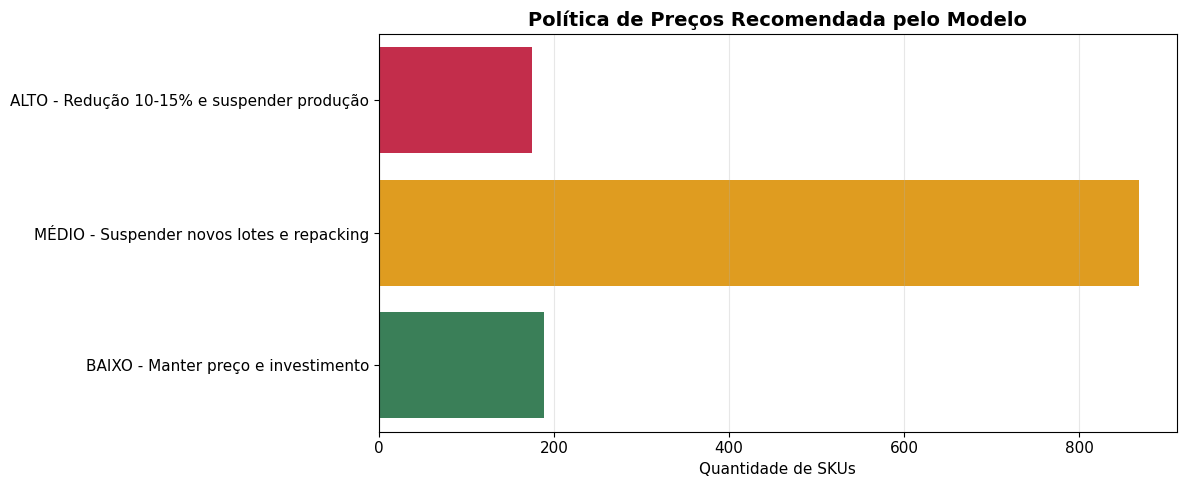

In [19]:
# ============================================================
# 14.1 POLÍTICA DE PREÇOS BASEADA NO MODELO
# ============================================================

def politica_preco_modelo(row):
    prob = row['prob_declinio_proximos_25']
    ciclo = row['ciclo_declinio_previsto']
    if prob > 0.50:
        if pd.notna(ciclo) and ciclo <= 5:
            return 'URGENTE - Phase-out imediato (<5 ciclos)'
        return 'ALTO - Redução 10-15% e suspender produção'
    elif prob > 0.30:
        return 'MÉDIO - Suspender novos lotes e repacking'
    else:
        return 'BAIXO - Manter preço e investimento'

df_margem['politica'] = df_margem.apply(politica_preco_modelo, axis=1)

politica_contagem = df_margem['politica'].value_counts()
politica_pct = (df_margem['politica'].value_counts(normalize=True)*100).round(1)

print('\n--- Política de Preços (baseada no modelo) ---\n')
display(pd.DataFrame({'Quantidade': politica_contagem, '% Portfólio': politica_pct}))

# Gráfico
ordem_pol = ['URGENTE - Phase-out imediato (<5 ciclos)',
             'ALTO - Redução 10-15% e suspender produção',
             'MÉDIO - Suspender novos lotes e repacking',
             'BAIXO - Manter preço e investimento']
cores_pol = ['darkred','crimson','orange','seagreen']
ordem_exist = [o for o in ordem_pol if o in politica_contagem.index]
cores_exist = [cores_pol[ordem_pol.index(o)] for o in ordem_exist]

plt.figure(figsize=(12, 5))
sns.countplot(data=df_margem, y='politica', order=ordem_exist, palette=cores_exist)
plt.title('Política de Preços Recomendada pelo Modelo', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de SKUs')
plt.ylabel('')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

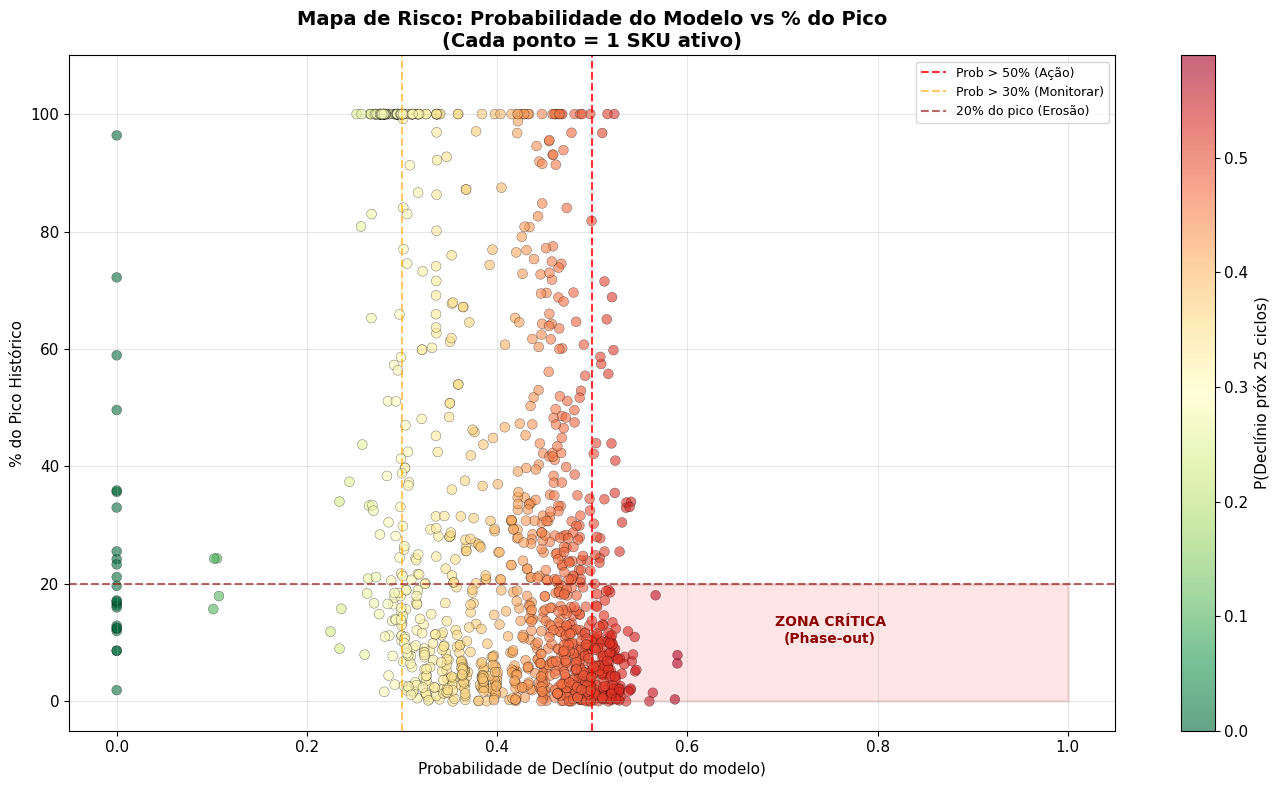

In [20]:
# ============================================================
# 14.2 MAPA DE RISCO: Probabilidade do Modelo vs % do Pico
# ============================================================

from matplotlib.patches import Rectangle

plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    df_margem['prob_declinio_proximos_25'],
    df_margem['pct_pico'] * 100,
    c=df_margem['prob_declinio_proximos_25'],
    cmap='RdYlGn_r', alpha=0.6, s=50, edgecolors='black', linewidth=0.3,
)
plt.axvline(0.50, ls='--', color='red', alpha=0.8, label='Prob > 50% (Ação)')
plt.axvline(0.30, ls='--', color='orange', alpha=0.6, label='Prob > 30% (Monitorar)')
plt.axhline(20, ls='--', color='darkred', alpha=0.6, label='20% do pico (Erosão)')

# Zona crítica
rect = Rectangle((0.5, 0), 0.5, 20, lw=2, edgecolor='darkred', facecolor='red', alpha=0.1)
plt.gca().add_patch(rect)
plt.text(0.75, 10, 'ZONA CRÍTICA\n(Phase-out)', ha='center', fontsize=10, color='darkred', fontweight='bold')

plt.colorbar(scatter, label='P(Declínio próx 25 ciclos)')
plt.title('Mapa de Risco: Probabilidade do Modelo vs % do Pico\n(Cada ponto = 1 SKU ativo)', fontsize=14, fontweight='bold')
plt.xlabel('Probabilidade de Declínio (output do modelo)')
plt.ylabel('% do Pico Histórico')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.ylim(-5, 110)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Produtos com Ticket Médio Enganoso: 444 (36.0%)
(Ticket alto + PDVs caindo + modelo prevê declínio → margem total em risco)


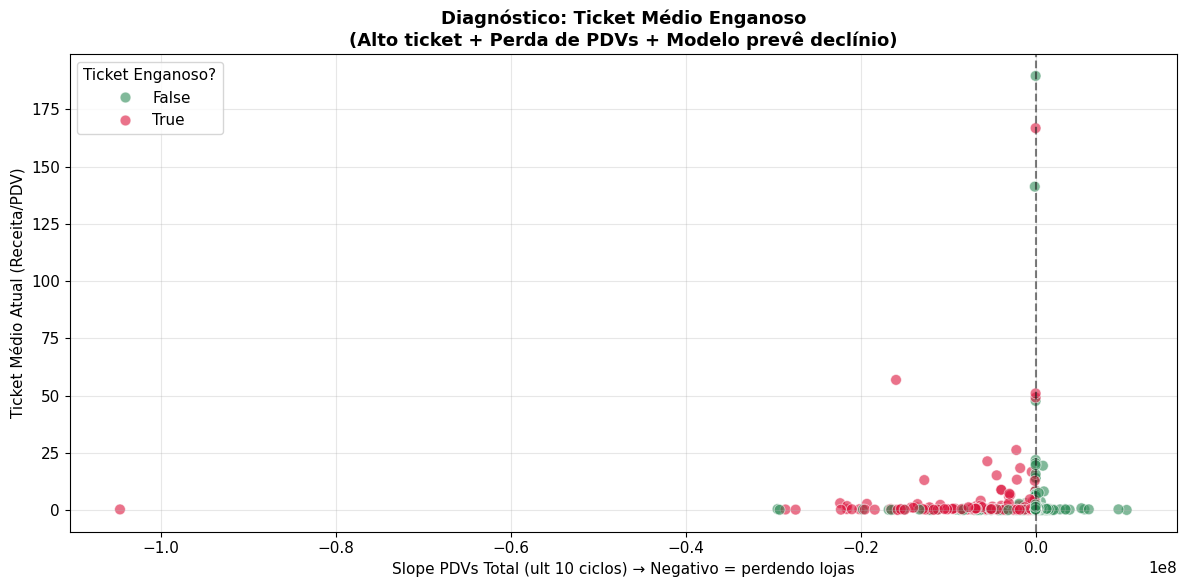

In [21]:
# ============================================================
# 14.3 TICKET MÉDIO ENGANOSO (modelo + indicador)
# ============================================================

df_margem['ticket_enganoso'] = (
    (df_margem['ticket_atual'] > df_margem['ticket_mediana']) &
    (df_margem['slope_cpfs_ult10'] < 0) &
    (df_margem['prob_declinio_proximos_25'] > 0.30)
)

n_enganoso = df_margem['ticket_enganoso'].sum()
print(f'Produtos com Ticket Médio Enganoso: {n_enganoso} ({n_enganoso/n_ativos*100:.1f}%)')
print('(Ticket alto + PDVs caindo + modelo prevê declínio → margem total em risco)')

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_margem, x='slope_cpfs_ult10', y='ticket_atual',
    hue='ticket_enganoso', palette={True:'crimson', False:'seagreen'}, alpha=0.6, s=60,
)
plt.axvline(0, ls='--', color='black', alpha=0.5)
plt.title('Diagnóstico: Ticket Médio Enganoso\n(Alto ticket + Perda de PDVs + Modelo prevê declínio)', fontsize=13, fontweight='bold')
plt.xlabel('Slope PDVs Total (ult 10 ciclos) → Negativo = perdendo lojas')
plt.ylabel('Ticket Médio Atual (Receita/PDV)')
plt.legend(title='Ticket Enganoso?')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

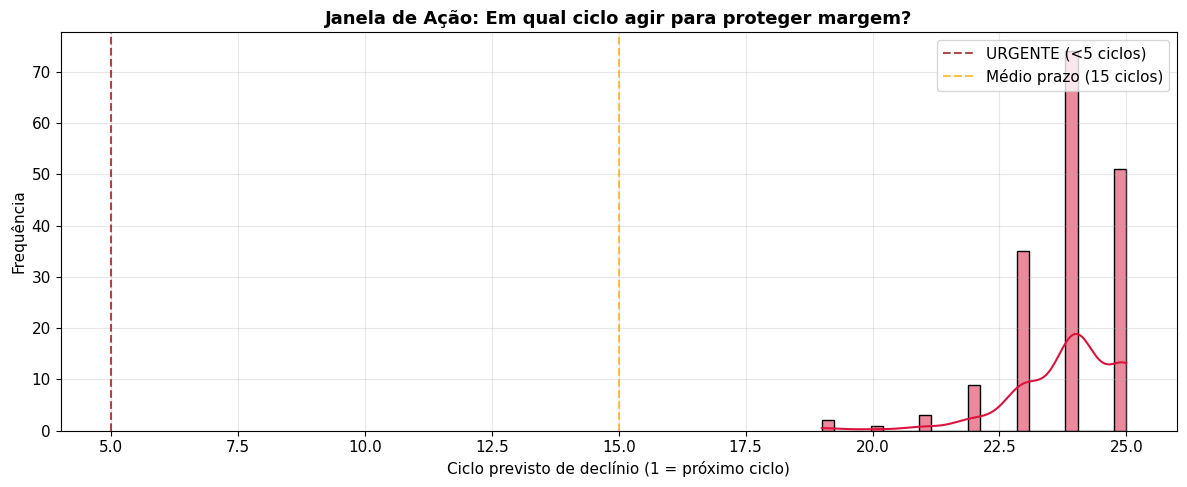


  Urgente (<5 ciclos):   0 SKUs → Phase-out imediato
  Médio (5-15 ciclos):   0 SKUs → Suspender produção
  Longo (15-25 ciclos):  175 SKUs → Planejar transição


In [22]:
# ============================================================
# 14.4 TIMING: JANELA DE AÇÃO (quando intervir?)
# ============================================================

declina_margem = df_margem[df_margem['previsao_declina'] == 1]

if len(declina_margem) > 0:
    plt.figure(figsize=(12, 5))
    sns.histplot(declina_margem['ciclo_declinio_previsto'].dropna(), bins=25, kde=True, color='crimson')
    plt.axvline(5, ls='--', color='darkred', alpha=0.7, label='URGENTE (<5 ciclos)')
    plt.axvline(15, ls='--', color='orange', alpha=0.7, label='Médio prazo (15 ciclos)')
    plt.title('Janela de Ação: Em qual ciclo agir para proteger margem?', fontsize=13, fontweight='bold')
    plt.xlabel('Ciclo previsto de declínio (1 = próximo ciclo)')
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    n_urgente = (declina_margem['ciclo_declinio_previsto'] <= 5).sum()
    n_medio = ((declina_margem['ciclo_declinio_previsto'] > 5) & (declina_margem['ciclo_declinio_previsto'] <= 15)).sum()
    n_longo = (declina_margem['ciclo_declinio_previsto'] > 15).sum()
    print(f'\n  Urgente (<5 ciclos):   {n_urgente} SKUs → Phase-out imediato')
    print(f'  Médio (5-15 ciclos):   {n_medio} SKUs → Suspender produção')
    print(f'  Longo (15-25 ciclos):  {n_longo} SKUs → Planejar transição')
else:
    print('Nenhum produto com prob > 50%. Usar ranking de risco para priorizar.')

In [23]:
# ============================================================
# 14.5 LISTA DE AÇÃO: SKUs PARA PHASE-OUT
# ============================================================

print('='*70)
print('  LISTA DE AÇÃO: SKUs PARA PROTEÇÃO DE MARGEM')
print('='*70)

# Critério: modelo + indicadores confirmam
df_margem['phase_out_recomendado'] = (
    (df_margem['prob_declinio_proximos_25'] > 0.50) &
    (df_margem['pct_pico'] < 0.40) &
    (df_margem['slope_cpfs_ult10'] < 0)
)

lista_acao = df_margem[df_margem['phase_out_recomendado']].sort_values('prob_declinio_proximos_25', ascending=False)

print(f'\nSKUs para ação imediata: {len(lista_acao)} ({len(lista_acao)/n_ativos*100:.1f}% do portfólio)')

if len(lista_acao) > 0:
    print('\n--- Top 20 ---')
    display(
        lista_acao.head(20)[['sk_produto_case','prob_declinio_proximos_25','ciclo_declinio_previsto','pct_pico','ciclos_desde_pico','slope_cpfs_ult10','ruptura_ult10']]
        .rename(columns={
            'prob_declinio_proximos_25': 'P(Declínio)',
            'ciclo_declinio_previsto': 'Declina ciclo',
            'pct_pico': '% Pico',
            'ciclos_desde_pico': 'Sem pico há',
            'slope_cpfs_ult10': 'Slope PDVs',
            'ruptura_ult10': '% Ruptura',
        })
    )
else:
    print('\nNenhum SKU atende todos os critérios combinados.')
    print('Usando ranking do modelo (Top 20 maior risco):')
    display(
        df_margem.sort_values('prob_declinio_proximos_25', ascending=False)
        .head(20)[['sk_produto_case','prob_declinio_proximos_25','ciclo_declinio_previsto','pct_pico','slope_cpfs_ult10']]
    )

  LISTA DE AÇÃO: SKUs PARA PROTEÇÃO DE MARGEM

SKUs para ação imediata: 118 (9.6% do portfólio)

--- Top 20 ---


,sk_produto_case,P(Declínio),Declina ciclo,% Pico,Sem pico há,Slope PDVs,% Ruptura
355,872,0.589554,21.0,7.872553e-02,44,-5.080662e+05,1.0
959,2098,0.589396,21.0,6.453707e-02,42,-1.049828e+06,1.0
762,1605,0.586849,19.0,3.319962e-03,47,-5.216116e+05,0.0
945,2072,0.566553,20.0,1.806777e-01,46,-3.058619e+05,1.0
329,825,0.563634,19.0,1.463697e-02,41,-2.421939e+04,1.0
774,1647,0.560006,21.0,4.674298e-05,24,-1.633606e+03,0.0
814,1801,0.546349,22.0,5.357524e-02,25,-4.431032e+04,0.0
320,795,0.545005,22.0,5.095525e-02,37,-4.422759e+04,1.0
449,1016,0.544595,23.0,1.096766e-01,24,-1.459757e+05,1.0
342,846,0.542829,22.0,7.995645e-02,19,-5.038130e+05,1.0


---
## 15. ROI: Realocação Inteligente de Verba de Marketing

In [25]:
# ============================================================
# ROI: REALOCAÇÃO INTELIGENTE DE VERBA DE MARKETING
# Evidência: Kruskal-Wallis prova que marketing NÃO altera
# performance de produtos em declínio (p = 0.45)
# ============================================================

print('='*70)
print('  ROI: REALOCAÇÃO INTELIGENTE DE VERBA DE MARKETING')
print('='*70)

# Marketing por produto e status
if 'vlr_investimento_mkt_direto' in df.columns:
    mkt_por_status = df.groupby('sk_produto_case').agg(
        status=('des_status_atual_agrup', 'first'),
        mkt_medio=('vlr_investimento_mkt_direto', 'mean'),
        mkt_total=('vlr_investimento_mkt_direto', 'sum'),
        categoria=('des_categoria_portfolio', 'first'),
    ).reset_index()

    print('\n--- Investimento em Marketing por Status ---')
    for status in ['Ativo', 'Inativo']:
        dados = mkt_por_status[mkt_por_status['status'] == status]['mkt_medio']
        print(f'  {status}: mediana = {dados.median():.2f} | média = {dados.mean():.2f}')

    # Teste estatístico
    from scipy.stats import kruskal
    ativos_mkt = mkt_por_status[mkt_por_status['status']=='Ativo']['mkt_medio'].dropna()
    inativos_mkt = mkt_por_status[mkt_por_status['status']=='Inativo']['mkt_medio'].dropna()
    stat_h, p_valor = kruskal(ativos_mkt, inativos_mkt)
    print(f'\n  Kruskal-Wallis: H = {stat_h:.4f}, p = {p_valor:.4f}')
    print(f'  Significativo: {"SIM" if p_valor < 0.05 else "NÃO"}')
    if p_valor > 0.05:
        print('  → Marketing NÃO diferencia Ativos de Inativos')
        print('  → Verba em produtos em declínio = investimento sem retorno')

  ROI: REALOCAÇÃO INTELIGENTE DE VERBA DE MARKETING

--- Investimento em Marketing por Status ---
  Ativo: mediana = 225790.70 | média = 227002.93
  Inativo: mediana = 226617.57 | média = 226881.62

  Kruskal-Wallis: H = 0.2475, p = 0.6188
  Significativo: NÃO
  → Marketing NÃO diferencia Ativos de Inativos
  → Verba em produtos em declínio = investimento sem retorno



--- Taxa de Inativação e Marketing por Categoria ---



,categoria,n_produtos,n_inativos,mkt_medio_cat,taxa_inativacao
0,Corpo e Banho,1645,1119,227241.261423,68.0
1,Perfumaria,817,425,226293.806736,52.0


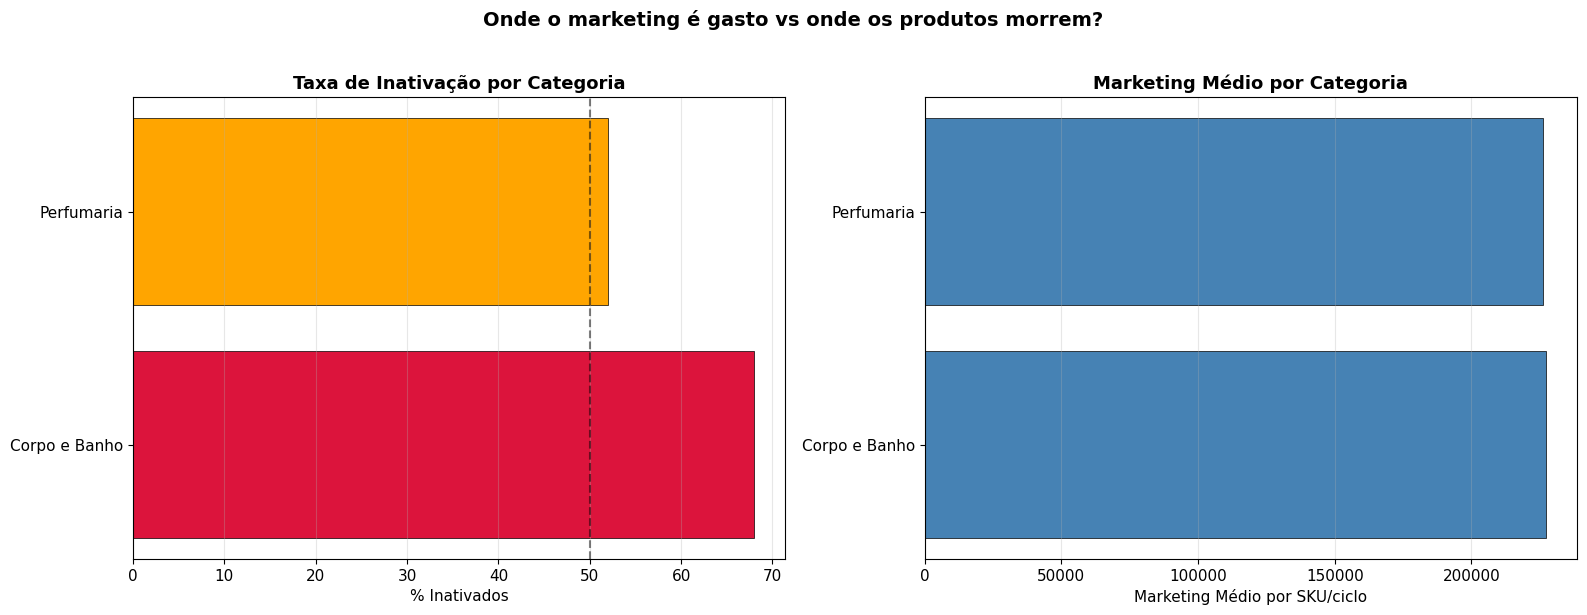

In [26]:
# Taxa de inativação por categoria
taxa_cat = mkt_por_status.groupby('categoria').agg(
    n_produtos=('sk_produto_case','count'),
    n_inativos=('status', lambda x: (x=='Inativo').sum()),
    mkt_medio_cat=('mkt_medio','mean'),
).reset_index()
taxa_cat['taxa_inativacao'] = (taxa_cat['n_inativos'] / taxa_cat['n_produtos'] * 100).round(1)
taxa_cat = taxa_cat.sort_values('taxa_inativacao', ascending=False)

print('\n--- Taxa de Inativação e Marketing por Categoria ---\n')
display(taxa_cat)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cores = ['crimson' if t > 60 else 'orange' if t > 50 else 'seagreen' for t in taxa_cat['taxa_inativacao']]
axes[0].barh(taxa_cat['categoria'], taxa_cat['taxa_inativacao'], color=cores, edgecolor='black', linewidth=0.5)
axes[0].axvline(50, ls='--', color='black', alpha=0.5)
axes[0].set_title('Taxa de Inativação por Categoria', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% Inativados')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(taxa_cat['categoria'], taxa_cat['mkt_medio_cat'], color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title('Marketing Médio por Categoria', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Marketing Médio por SKU/ciclo')
axes[1].grid(True, alpha=0.3, axis='x')
plt.suptitle('Onde o marketing é gasto vs onde os produtos morrem?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

SKUs alto risco com marketing: 1043
Verba total desperdiçada: 5,475,256,889.00



,categoria,verba_desperdicada
0,Corpo e Banho,3977021201
1,Perfumaria,1498235688


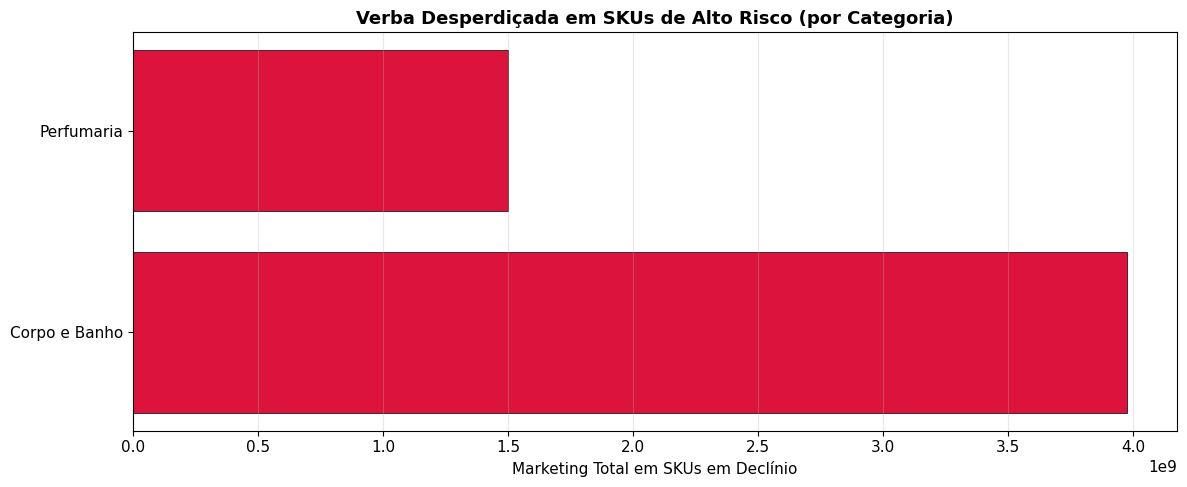

In [27]:
# Verba desperdiçada em SKUs de alto risco
skus_risco_mkt = df_vivos[df_vivos['prob_declinio_proximos_25'] > 0.30]['sk_produto_case'].values
mkt_risco = mkt_por_status[mkt_por_status['sk_produto_case'].isin(skus_risco_mkt)]

verba_por_cat = mkt_risco.groupby('categoria')['mkt_total'].sum().sort_values(ascending=False).reset_index(name='verba_desperdicada')
total_desperdicado = verba_por_cat['verba_desperdicada'].sum()

print(f'SKUs alto risco com marketing: {len(mkt_risco)}')
print(f'Verba total desperdiçada: {total_desperdicado:,.2f}\n')
display(verba_por_cat)

plt.figure(figsize=(12, 5))
plt.barh(verba_por_cat['categoria'], verba_por_cat['verba_desperdicada'], color='crimson', edgecolor='black', linewidth=0.5)
plt.title('Verba Desperdiçada em SKUs de Alto Risco (por Categoria)', fontsize=13, fontweight='bold')
plt.xlabel('Marketing Total em SKUs em Declínio')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# SIMULAÇÃO: REALOCAÇÃO DE VERBA
# ============================================================

# Categorias origem (alta rotatividade) e destino (baixa rotatividade)
categorias_origem = taxa_cat[taxa_cat['taxa_inativacao'] > 60]['categoria'].values
categorias_destino = taxa_cat[taxa_cat['taxa_inativacao'] <= 50]['categoria'].values

print('Categorias ORIGEM (alta rotatividade → marketing ineficaz):')
for cat in categorias_origem:
    print(f'  - {cat} ({taxa_cat[taxa_cat["categoria"]==cat]["taxa_inativacao"].values[0]}% inativação)')
print('\nCategorias DESTINO (baixa rotatividade → marketing com retorno):')
for cat in categorias_destino:
    print(f'  - {cat} ({taxa_cat[taxa_cat["categoria"]==cat]["taxa_inativacao"].values[0]}% inativação)')

# Verba realocável
verba_realocavel = mkt_risco[mkt_risco['categoria'].isin(categorias_origem)]['mkt_total'].sum()
print(f'\nVerba realocável: {verba_realocavel:,.2f}')

# Cenários
cenarios = {
    'Conservador': {'pct': 0.50, 'roi': 1.5},
    'Realista': {'pct': 0.70, 'roi': 2.5},
    'Otimista': {'pct': 0.90, 'roi': 4.0},
}

result_mkt = []
for nome, p in cenarios.items():
    verba = verba_realocavel * p['pct']
    retorno = verba * p['roi']
    ganho = retorno - verba + verba  # economia + retorno
    result_mkt.append({'Cenário': nome, '% Realocada': p['pct']*100, 'Verba': verba, 'ROI Destino': p['roi'], 'Retorno': retorno, 'Ganho Líquido': ganho})

df_mkt_roi = pd.DataFrame(result_mkt)
print('\n--- Cenários de ROI ---\n')
display(df_mkt_roi)

Categorias ORIGEM (alta rotatividade → marketing ineficaz):
  - Corpo e Banho (68.0% inativação)

Categorias DESTINO (baixa rotatividade → marketing com retorno):

Verba realocável: 3,977,021,201.00

--- Cenários de ROI ---



,Cenário,% Realocada,Verba,ROI Destino,Retorno,Ganho Líquido
0,Conservador,50.0,1.988511e+09,1.5,2.982766e+09,2.982766e+09
1,Realista,70.0,2.783915e+09,2.5,6.959787e+09,6.959787e+09
2,Otimista,90.0,3.579319e+09,4.0,1.431728e+10,1.431728e+10


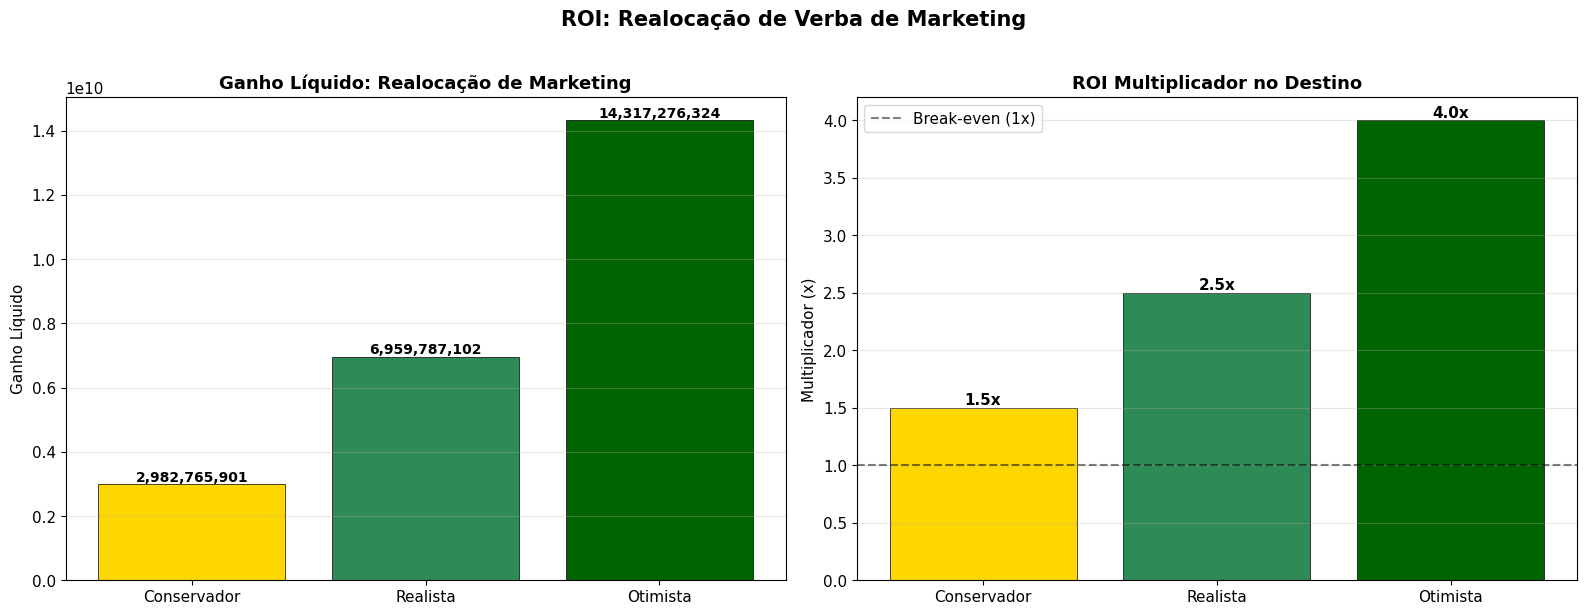

In [30]:
# Gráfico ROI
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ganho por cenário
cores_c = ['gold','seagreen','darkgreen']
axes[0].bar(df_mkt_roi['Cenário'], df_mkt_roi['Ganho Líquido'], color=cores_c, edgecolor='black', linewidth=0.5)
for i, v in enumerate(df_mkt_roi['Ganho Líquido']):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Ganho Líquido: Realocação de Marketing', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ganho Líquido')
axes[0].grid(True, alpha=0.3, axis='y')

# ROI multiplicador
axes[1].bar(df_mkt_roi['Cenário'], df_mkt_roi['ROI Destino'], color=cores_c, edgecolor='black', linewidth=0.5)
axes[1].axhline(1, ls='--', color='black', alpha=0.5, label='Break-even (1x)')
for i, v in enumerate(df_mkt_roi['ROI Destino']):
    axes[1].text(i, v, f'{v}x', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('ROI Multiplicador no Destino', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Multiplicador (x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('ROI: Realocação de Verba de Marketing', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 16. Simulação de ROI: Cenários de Proteção de Margem

In [32]:
# ============================================================
# SIMULAÇÃO DE ROI - CENÁRIOS DE PROTEÇÃO DE MARGEM
# ============================================================

print('='*70)
print('  SIMULAÇÃO DE ROI - PROTEÇÃO DE MARGEM')
print('='*70)

# --- Parâmetros base ---
# Receita média dos SKUs em risco (últimos dados disponíveis)
skus_risco = df_margem[df_margem['prob_declinio_proximos_25'] > 0.30]
n_skus_risco = len(skus_risco)

# Receita média por SKU em risco (por ciclo)
receita_media_ciclo = df_sorted.merge(
    skus_risco[['sk_produto_case']], on='sk_produto_case'
).groupby('sk_produto_case')['ind_vlr_receita_real_corrigido'].mean().median()

print(f'\n--- Parâmetros da Simulação ---')
print(f'  SKUs em risco (prob > 30%): {n_skus_risco}')
print(f'  Receita mediana por SKU/ciclo: {receita_media_ciclo:,.2f}')
print(f'  Horizonte: {HORIZONTE} ciclos')

  SIMULAÇÃO DE ROI - PROTEÇÃO DE MARGEM

--- Parâmetros da Simulação ---
  SKUs em risco (prob > 30%): 1043
  Receita mediana por SKU/ciclo: 6,206,050.95
  Horizonte: 25 ciclos


In [33]:
# ============================================================
# CENÁRIOS DE DESCONTO
# ============================================================

# Premissas:
# - SEM modelo: empresa age tarde → precisa dar descontos agressivos
# - COM modelo: empresa age cedo → vende a preço cheio ou desconto menor

cenarios = {
    'Conservador': {
        'desconto_sem_modelo': 0.30,   # 30% desconto sem ação proativa
        'desconto_com_modelo': 0.10,   # 10% desconto com ação antecipada
        'pct_skus_salvos': 0.50,       # 50% dos SKUs detectados são salvos
        'ciclos_antecipacao': 5,       # Age 5 ciclos antes
    },
    'Realista': {
        'desconto_sem_modelo': 0.45,   # 45% desconto (liquidação)
        'desconto_com_modelo': 0.10,   # 10% desconto controlado
        'pct_skus_salvos': 0.65,       # 65% detectados corretamente
        'ciclos_antecipacao': 10,      # Age 10 ciclos antes
    },
    'Otimista': {
        'desconto_sem_modelo': 0.55,   # 55% desconto (queima total)
        'desconto_com_modelo': 0.05,   # 5% desconto mínimo
        'pct_skus_salvos': 0.80,       # 80% detectados corretamente
        'ciclos_antecipacao': 15,      # Age 15 ciclos antes
    },
}

resultados_roi = []

for nome, params in cenarios.items():
    # Receita total em risco (SKUs * ciclos * receita média)
    n_salvos = int(n_skus_risco * params['pct_skus_salvos'])
    ciclos_antecip = params['ciclos_antecipacao']

    # Cenário SEM modelo: vende com desconto agressivo no final
    receita_sem_modelo = receita_media_ciclo * n_salvos * ciclos_antecip * (1 - params['desconto_sem_modelo'])

    # Cenário COM modelo: age cedo, vende com desconto menor
    receita_com_modelo = receita_media_ciclo * n_salvos * ciclos_antecip * (1 - params['desconto_com_modelo'])

    # Margem protegida
    margem_protegida = receita_com_modelo - receita_sem_modelo

    # Receita total a preço cheio (referência)
    receita_preco_cheio = receita_media_ciclo * n_salvos * ciclos_antecip

    # ROI: margem salva / custo do modelo (assumindo custo zero do modelo)
    pct_margem_salva = (margem_protegida / receita_preco_cheio) * 100

    resultados_roi.append({
        'Cenário': nome,
        'SKUs Salvos': n_salvos,
        'Ciclos Antecipação': ciclos_antecip,
        'Desconto SEM Modelo (%)': params['desconto_sem_modelo'] * 100,
        'Desconto COM Modelo (%)': params['desconto_com_modelo'] * 100,
        'Receita SEM Modelo': receita_sem_modelo,
        'Receita COM Modelo': receita_com_modelo,
        'Margem Protegida': margem_protegida,
        '% Margem Salva': pct_margem_salva,
    })

df_roi = pd.DataFrame(resultados_roi)
print('\n--- Resultados por Cenário ---\n')
display(df_roi[['Cenário','SKUs Salvos','Ciclos Antecipação','Desconto SEM Modelo (%)',
                'Desconto COM Modelo (%)','Margem Protegida','% Margem Salva']].round(1))


--- Resultados por Cenário ---



,Cenário,SKUs Salvos,Ciclos Antecipação,Desconto SEM Modelo (%),Desconto COM Modelo (%),Margem Protegida,% Margem Salva
0,Conservador,521,5,30.0,10.0,3.233353e+09,20.0
1,Realista,677,10,45.0,10.0,1.470524e+10,35.0
2,Otimista,834,15,55.0,5.0,3.881885e+10,50.0


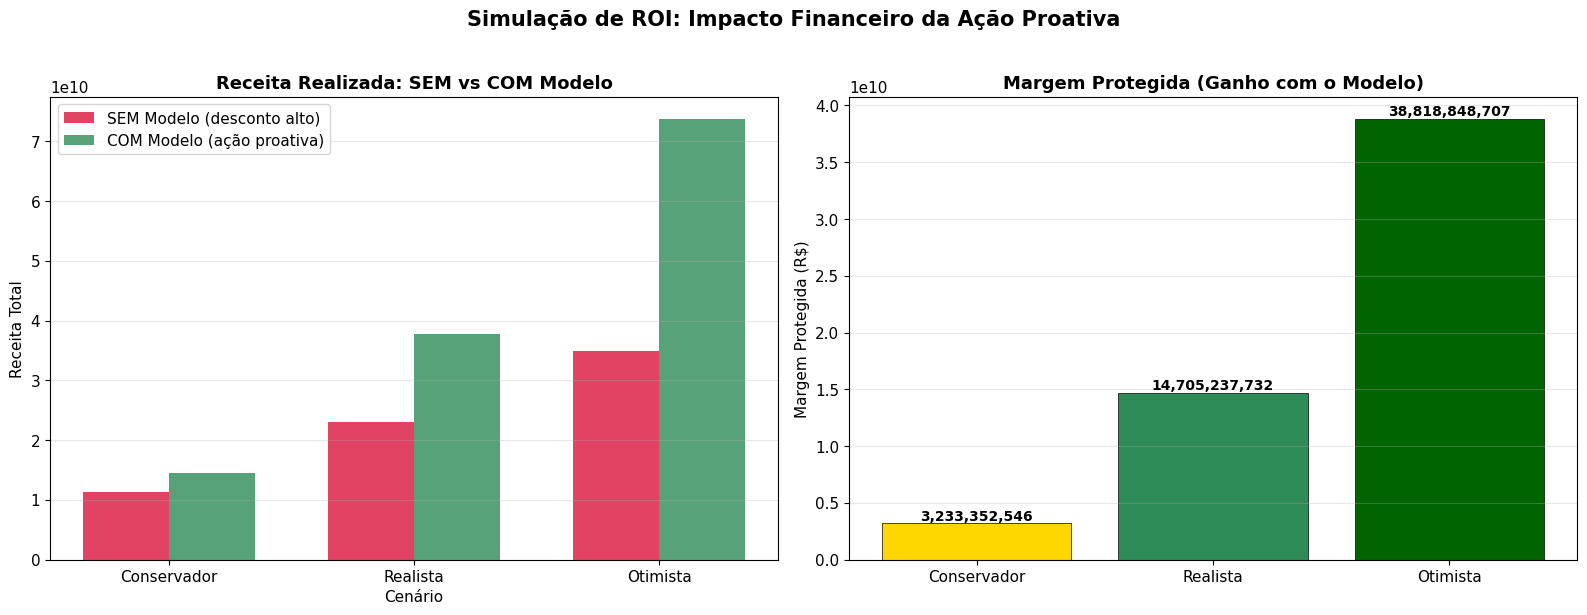

In [34]:
# ============================================================
# GRÁFICO 1: Comparação Receita SEM vs COM modelo
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras comparativas
x = np.arange(len(df_roi))
width = 0.35

bars1 = axes[0].bar(x - width/2, df_roi['Receita SEM Modelo'], width, label='SEM Modelo (desconto alto)', color='crimson', alpha=0.8)
bars2 = axes[0].bar(x + width/2, df_roi['Receita COM Modelo'], width, label='COM Modelo (ação proativa)', color='seagreen', alpha=0.8)

axes[0].set_xlabel('Cenário')
axes[0].set_ylabel('Receita Total')
axes[0].set_title('Receita Realizada: SEM vs COM Modelo', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_roi['Cenário'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Margem protegida
cores_cenario = ['gold', 'seagreen', 'darkgreen']
axes[1].bar(df_roi['Cenário'], df_roi['Margem Protegida'], color=cores_cenario, edgecolor='black', linewidth=0.5)
axes[1].set_title('Margem Protegida (Ganho com o Modelo)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Margem Protegida (R$)')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(df_roi['Margem Protegida']):
    axes[1].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Simulação de ROI: Impacto Financeiro da Ação Proativa', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# GRÁFICO 2: Cascata de Valor (Waterfall)
# ============================================================

# Cenário realista detalhado
cr = cenarios['Realista']
n_salvos_r = int(n_skus_risco * cr['pct_skus_salvos'])
receita_cheio = receita_media_ciclo * n_salvos_r * cr['ciclos_antecipacao']

cascata = {
    'Receita a\npreço cheio': receita_cheio,
    'Perda SEM\nmodelo (-45%)': -receita_cheio * cr['desconto_sem_modelo'],
    'Receita\nSEM modelo': receita_cheio * (1 - cr['desconto_sem_modelo']),
    'Margem\nprotegida': receita_cheio * (cr['desconto_sem_modelo'] - cr['desconto_com_modelo']),
    'Receita\nCOM modelo': receita_cheio * (1 - cr['desconto_com_modelo']),
}

fig, ax = plt.subplots(figsize=(14, 6))

labels = list(cascata.keys())
values = list(cascata.values())
colors = ['steelblue', 'crimson', 'lightcoral', 'seagreen', 'darkgreen']

ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.5)
for i, (label, val) in enumerate(zip(labels, values)):
    ax.text(i, val, f'{val:,.0f}', ha='center', va='bottom' if val > 0 else 'top', fontsize=9, fontweight='bold')

ax.set_title('Cascata de Valor - Cenário Realista\n(Como o modelo protege a margem)', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor (R$)')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

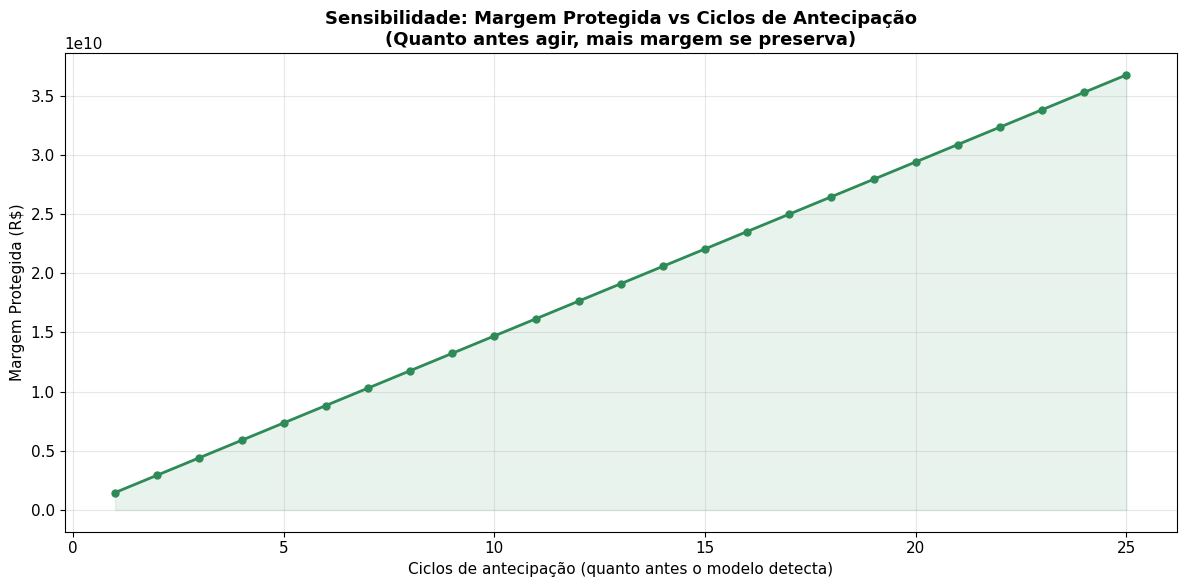


Margem protegida por ciclo de antecipação (cenário realista):
  1 ciclo:   1,470,523,773.17
  5 ciclos:  7,352,618,865.83
  10 ciclos: 14,705,237,731.67
  15 ciclos: 22,057,856,597.50
  25 ciclos: 36,763,094,329.17


In [35]:
# ============================================================
# GRÁFICO 3: Sensibilidade - Margem vs Ciclos de Antecipação
# ============================================================

ciclos_range = range(1, 26)
margem_por_ciclo = []

for c in ciclos_range:
    n_salvos_s = int(n_skus_risco * 0.65)  # Cenário realista
    receita_sem = receita_media_ciclo * n_salvos_s * c * (1 - 0.45)
    receita_com = receita_media_ciclo * n_salvos_s * c * (1 - 0.10)
    margem_por_ciclo.append(receita_com - receita_sem)

plt.figure(figsize=(12, 6))
plt.plot(list(ciclos_range), margem_por_ciclo, marker='o', linewidth=2, color='seagreen', markersize=5)
plt.fill_between(list(ciclos_range), margem_por_ciclo, alpha=0.1, color='seagreen')
plt.title('Sensibilidade: Margem Protegida vs Ciclos de Antecipação\n(Quanto antes agir, mais margem se preserva)', fontsize=13, fontweight='bold')
plt.xlabel('Ciclos de antecipação (quanto antes o modelo detecta)')
plt.ylabel('Margem Protegida (R$)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nMargem protegida por ciclo de antecipação (cenário realista):')
print(f'  1 ciclo:   {margem_por_ciclo[0]:>15,.2f}')
print(f'  5 ciclos:  {margem_por_ciclo[4]:>15,.2f}')
print(f'  10 ciclos: {margem_por_ciclo[9]:>15,.2f}')
print(f'  15 ciclos: {margem_por_ciclo[14]:>15,.2f}')
print(f'  25 ciclos: {margem_por_ciclo[24]:>15,.2f}')

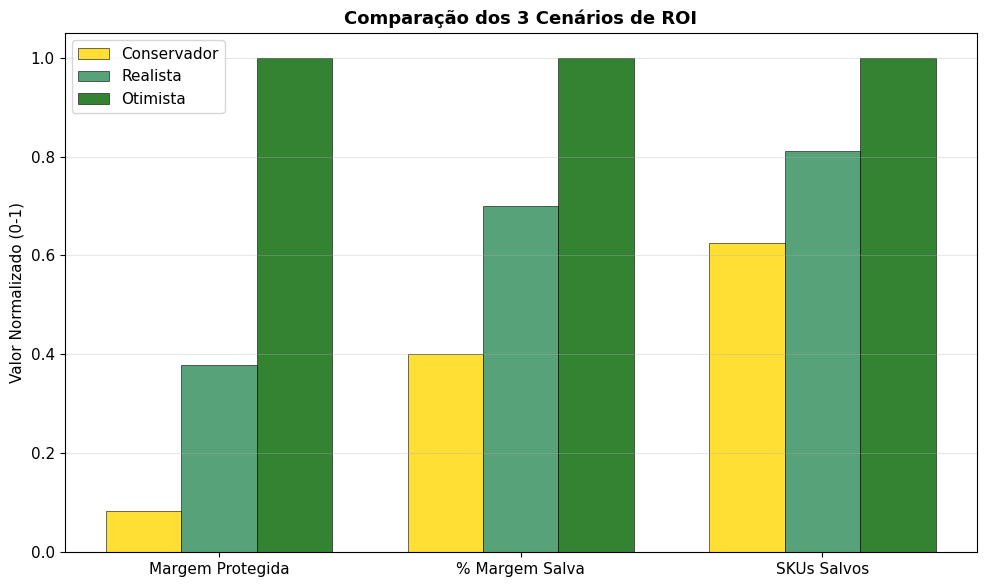

In [36]:
# ============================================================
# GRÁFICO 4: Comparação dos 3 Cenários (Spider/Radar simplificado)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['Margem Protegida', '% Margem Salva', 'SKUs Salvos']
x_pos = np.arange(len(metricas))
width = 0.25

for i, (_, row) in enumerate(df_roi.iterrows()):
    valores_norm = [
        row['Margem Protegida'] / df_roi['Margem Protegida'].max(),
        row['% Margem Salva'] / df_roi['% Margem Salva'].max(),
        row['SKUs Salvos'] / df_roi['SKUs Salvos'].max(),
    ]
    ax.bar(x_pos + i*width, valores_norm, width, label=row['Cenário'],
           color=cores_cenario[i], alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(metricas)
ax.set_ylabel('Valor Normalizado (0-1)')
ax.set_title('Comparação dos 3 Cenários de ROI', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()